# Compare Cuts
The purpose of this notebook is to compare two different selections and see how that effects their histograms. Particular focus will be put on how different cuts effect the LJ_LJ_invariant mass plots. 

The first cut I'll study is the `4MU_SR` cut, which is meant to isolate a 4mu signal region. 

The second cut I'll study is the same as the above, but also restricting the DSA muons to only the barrel. From the previous notebook, plots suggested that the background far exceeded the signal outside of the barrel for the DSA muons. 

I've added the `lj_lj_invmass` histogram to the `lj_eta_study` hist_collection so I can investigate the effect of restricting the DSA muons to only the barrel. 

## Imports

In [1]:
# python
import sys
import os
import importlib
# columnar analysis
import coffea
from coffea import processor
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
import awkward as ak
from dask.distributed import Client, performance_report
import hist
import numpy as np
# local
sidm_path = str(sys.path[0]).split("/sidm")[0]
# sys.path.insert(1, os.path.join(sys.path[0], '../../..')) # from ABCD_study notebook
sidm_path = str(os.getcwd()).split("/sidm")[0]
if sidm_path not in sys.path: sys.path.insert(1, sidm_path)
from sidm.tools import utilities, sidm_processor, scaleout, cutflow, llpnanoaodschema
# always reload local modules to pick up changes during development
importlib.reload(utilities)
importlib.reload(sidm_processor)
importlib.reload(scaleout)
# plotting
import matplotlib.pyplot as plt
utilities.set_plot_style()
# %matplotlib inline
from tqdm.notebook import tqdm

In [2]:
#I DON'T THINK THIS METHOD WILL HAVE ACCESS TO THE RUNNER OBJECT TO CALL runner.run. 
#Try it out? Maybe pass the runner as a parameter. Could probably get the processor instance from the runner object
def processListAndSave(sample_list, file_type, max_files, location_cfg, processor_instance, output_dir, save=True):
    """
    Process a list of given samples (either data or background) and save each individual sample in a .coffea file
    sample_list -- a list of strings of samples to run over. Data will be overwritten if a duplicate sample string exists.
    file_type -- "llpNanoAOD_v2" or "skimmed_llpNanoAOD_v2" will be the most likely parameters
    max_files -- the maximum number of files to run over
    location_cfg -- the location of the .yaml configuration file
    output_dir -- the path to save the .coffea file to. It is relative to the directory you ran the file in.
    Returns:
    out -- A dictionary matching what you would normally use to plot histograms with all of the samples in sample_list
    runner.run()["out"]
    """
    channels = processor_instance.channel_names
    hist_collections = processor_instance.hist_collection_names
    dir_path = channels[0] + '_' + hist_collections[0]
    if save: #If we want to save .coffea files    
        os.makedirs(dir_path, exist_ok=True)
        print(f"Saving .coffea files at {dir_path}/output_'sample'.coffea")
    #Create an empty dict to update with each processed sample
    out = {}
    for sample in sample_list:
        print(f"Processing Sample: {sample}")
        #Create the fileset for one sample
        fileset = utilities.make_fileset([sample], file_type, max_files=max_files, location_cfg=location_cfg)
        output = runner.run(fileset, treename="Events", processor_instance=processor_instance)
        if save: coffea.util.save(output, f"{dir_path}/output_{sample}.coffea")
        #Concat each completed sample onto the dictionary. We know there won't be any key collisions, each sample has a different name
        out |= output["out"]
    return out

def useAllSamples():
    print("USING ALL 2MU2E AND ALL 4MU SAMPLES!!!")
    import yaml
    #Define all 2mu2e samples
    yaml_file_path_2mu2e = '../../configs/ntuples/signal_2mu2e_v10.yaml'
    # Open and read the YAML file
    with open(yaml_file_path_2mu2e, 'r') as file:
        data = yaml.safe_load(file)
    samples_2mu2e = list(data["llpNanoAOD_v2"]["samples"].keys())
    # print(samples_2mu2e)
    
    #Define all 4mu samples
    yaml_file_path_4mu = '../../configs/ntuples/signal_4mu_v10.yaml'
    # Open and read the YAML file
    with open(yaml_file_path_4mu, 'r') as file:
        data = yaml.safe_load(file)
    samples_4mu = list(data["llpNanoAOD_v2"]["samples"].keys())

    return samples2mu2e, samples4mu

### Useful Functions

In [3]:
def sum_bgs_hist(bgs_list, histogram_collection, histogram_name, channel_name):
    """
    Sum histograms for a list of backgrounds.
    """
    summed_hist = None
    #Set up the path to the bkg_file
    dir_path = channel_name + '_' + histogram_collection
    
    for bkg in bgs_list:
        # print(x)
        output_bg = coffea.util.load(f"{dir_path}/output_bkg_{bkg}.coffea")
        # print(output_bg)
        hist = output_bg["out"][bkg]["hists"][histogram_name][channel_name, ::4j]
        
        if summed_hist is None:
            summed_hist = hist.copy()
        else:
            summed_hist += hist
    
    return summed_hist

### Define Dask Client

In [4]:
# from dask.distributed import Client

# client = scaleout.make_dask_client("tls://localhost:8786")
# client

## Define Samples
Choose between running over a few samples or scanning the yaml file and running over all samples. 

In [5]:
useAllSamples = False
if useAllSamples:
    samples2mu2e, samples4mu = useAllSamples()
else:
    samples_2mu2e = ["2Mu2E_500GeV_5p0GeV_0p8mm", "2Mu2E_500GeV_5p0GeV_8p0mm"]
    #These were the samples that weren't giving me an issue. Though it seems to be fixed now as of 03/10/2026.
    samples_4mu = ["4Mu_500GeV_5p0GeV_0p8mm", "4Mu_500GeV_5p0GeV_8p0mm"]
    # "4Mu_100GeV_0p25GeV_0p02mm", "4Mu_100GeV_0p25GeV_0p2mm", "4Mu_100GeV_0p25GeV_2p0mm", "4Mu_100GeV_0p25GeV_10p0mm", "4Mu_100GeV_0p25GeV_20p0mm", "4Mu_100GeV_1p2GeV_0p096mm", "4Mu_100GeV_1p2GeV_0p96mm", "4Mu_100GeV_1p2GeV_9p6mm", "4Mu_100GeV_1p2GeV_48p0mm", "4Mu_100GeV_1p2GeV_96p0mm", "4Mu_100GeV_5p0GeV_0p4mm", "4Mu_100GeV_5p0GeV_4p0mm", "4Mu_100GeV_5p0GeV_40p0mm", "4Mu_100GeV_5p0GeV_200mm", "4Mu_100GeV_5p0GeV_400mm", "4Mu_150GeV_0p25GeV_0p013mm", "4Mu_150GeV_0p25GeV_0p13mm", "4Mu_150GeV_0p25GeV_1p3mm", "4Mu_150GeV_0p25GeV_6p7mm", "4Mu_150GeV_0p25GeV_13p0mm", "4Mu_150GeV_1p2GeV_0p064mm", "4Mu_150GeV_1p2GeV_0p64mm", "4Mu_150GeV_1p2GeV_6p4mm", "4Mu_150GeV_1p2GeV_32p0mm", "4Mu_150GeV_1p2GeV_64p0mm", "4Mu_150GeV_5p0GeV_0p27mm", "4Mu_150GeV_5p0GeV_2p7mm", "4Mu_150GeV_5p0GeV_27p0mm", "4Mu_150GeV_5p0GeV_130p0mm", "4Mu_150GeV_5p0GeV_270p0mm", "4Mu_200GeV_0p25GeV_0p01mm", "4Mu_200GeV_0p25GeV_0p1mm", "4Mu_200GeV_0p25GeV_1p0mm", "4Mu_200GeV_0p25GeV_5p0mm", "4Mu_200GeV_0p25GeV_10p0mm", "4Mu_200GeV_1p2GeV_0p048mm", "4Mu_200GeV_1p2GeV_0p48mm", "4Mu_200GeV_1p2GeV_4p8mm", "4Mu_200GeV_1p2GeV_24p0mm", "4Mu_200GeV_1p2GeV_48p0mm", "4Mu_200GeV_5p0GeV_0p2mm", "4Mu_200GeV_5p0GeV_2p0mm", "4Mu_200GeV_5p0GeV_20p0mm", "4Mu_200GeV_5p0GeV_100p0mm", "4Mu_200GeV_5p0GeV_200p0mm", "4Mu_500GeV_0p25GeV_0p004mm", "4Mu_500GeV_0p25GeV_0p04mm", "4Mu_500GeV_0p25GeV_0p4mm", "4Mu_500GeV_0p25GeV_2p0mm", "4Mu_500GeV_0p25GeV_4p0mm", "4Mu_500GeV_1p2GeV_0p019mm", "4Mu_500GeV_1p2GeV_0p19mm", "4Mu_500GeV_1p2GeV_1p9mm", "4Mu_500GeV_1p2GeV_9p6mm", "4Mu_500GeV_1p2GeV_19p0mm", "4Mu_500GeV_5p0GeV_0p08mm", "4Mu_500GeV_5p0GeV_0p8mm", "4Mu_500GeV_5p0GeV_8p0mm", "4Mu_500GeV_5p0GeV_40p0mm", "4Mu_500GeV_5p0GeV_80p0mm", "4Mu_800GeV_0p25GeV_0p0025mm", "4Mu_800GeV_0p25GeV_0p025mm", "4Mu_800GeV_0p25GeV_0p25mm", "4Mu_800GeV_0p25GeV_1p2mm", "4Mu_800GeV_0p25GeV_2p5mm", "4Mu_800GeV_1p2GeV_0p012mm", "4Mu_800GeV_1p2GeV_0p12mm", "4Mu_800GeV_1p2GeV_1p2mm", "4Mu_800GeV_1p2GeV_6p0mm", "4Mu_800GeV_1p2GeV_12p0mm", "4Mu_800GeV_5p0GeV_0p05mm", "4Mu_800GeV_5p0GeV_0p5mm", "4Mu_800GeV_5p0GeV_5p0mm", "4Mu_800GeV_5p0GeV_25p0mm", "4Mu_800GeV_5p0GeV_50p0mm", "4Mu_1000GeV_0p25GeV_0p002mm", "4Mu_1000GeV_0p25GeV_0p02mm", "4Mu_1000GeV_0p25GeV_0p2mm", "4Mu_1000GeV_0p25GeV_1p0mm"]

    print(f"Using Specific Samples:\n 2mu2e Samples:\n{samples_2mu2e}\n4mu Samples:\n{samples_4mu}")
    
samples = samples_2mu2e + samples_4mu

QCD=[
     "QCD_Pt15To20", 
     "QCD_Pt20To30", 
     "QCD_Pt30To50", 
     "QCD_Pt50To80", 
     "QCD_Pt80To120", 
     "QCD_Pt120To170", 
     "QCD_Pt170To300", 
     "QCD_Pt300To470", 
     "QCD_Pt470To600", 
     "QCD_Pt600To800", 
     "QCD_Pt800To1000", 
     "QCD_Pt1000"]
DY=["DYJetsToMuMu_M10to50", 
    "DYJetsToMuMu_M50"]
TT = ["TTJets"]
samples_bkg = QCD + DY + TT
print(f"Background:\n {samples_bkg}")

Using Specific Samples:
 2mu2e Samples:
['2Mu2E_500GeV_5p0GeV_0p8mm', '2Mu2E_500GeV_5p0GeV_8p0mm']
4mu Samples:
['4Mu_500GeV_5p0GeV_0p8mm', '4Mu_500GeV_5p0GeV_8p0mm']
Background:
 ['QCD_Pt15To20', 'QCD_Pt20To30', 'QCD_Pt30To50', 'QCD_Pt50To80', 'QCD_Pt80To120', 'QCD_Pt120To170', 'QCD_Pt170To300', 'QCD_Pt300To470', 'QCD_Pt470To600', 'QCD_Pt600To800', 'QCD_Pt800To1000', 'QCD_Pt1000', 'DYJetsToMuMu_M10to50', 'DYJetsToMuMu_M50', 'TTJets']


## Load Saved Output Data
We want to load in the saved data exactly as we would expect it coming from processing. 

`coffea.util.save()` saves the raw output from `runner.run()`. 

The output we want is in `output["out"]`.

### Load First Selections

In [6]:
#Define where to load the first set of data from
channel_1 = "4mu_SR"
hist_collection_1 = "lj_eta_study"
#Make the filepath for loading the outputs
dir_path_1 = channel_1 + '_' + hist_collection_1

#We want to load in the saved data exactly as we would expect it coming from processing. 
#coffea.util.save() saves the raw output from runner.run(). 
#The output we want is in output["out"]

#Load the samples
output_2mu2e = coffea.util.load(f"{dir_path_1}/output_signal_2mu2e.coffea")
out_2mu2e = output_2mu2e["out"]

output_4mu = coffea.util.load(f"{dir_path_1}/output_signal_4mu.coffea")
out_4mu = output_4mu["out"]

#Combine both outputs in the way the plotting code is expecting them
#See PEP-584 https://peps.python.org/pep-0584/
out_1 = out_2mu2e | out_4mu

#Load each background file
bkg_out_1 = {}
for bkg in samples_bkg:
    bkg_output = coffea.util.load(f"{dir_path_1}/output_bkg_{bkg}.coffea")
    #Concat each completed background sample onto the dictionary. We know there won't be any key collisions, each background has a different name
    bkg_out_1 |= bkg_output["out"]
    print(f"Loaded background: {bkg}")

Loaded background: QCD_Pt15To20
Loaded background: QCD_Pt20To30
Loaded background: QCD_Pt30To50
Loaded background: QCD_Pt50To80
Loaded background: QCD_Pt80To120
Loaded background: QCD_Pt120To170
Loaded background: QCD_Pt170To300
Loaded background: QCD_Pt300To470
Loaded background: QCD_Pt470To600
Loaded background: QCD_Pt600To800
Loaded background: QCD_Pt800To1000
Loaded background: QCD_Pt1000
Loaded background: DYJetsToMuMu_M10to50
Loaded background: DYJetsToMuMu_M50
Loaded background: TTJets


### Load Second Selections

In [7]:
#Define where to load the first set of data from
channel_2 = "4mu_SR_DSA_barrel"
# channel_2 = "4mu"
hist_collection_2 = "lj_eta_study"
#Make the filepath for loading the outputs
dir_path_2 = channel_2 + '_' + hist_collection_2

#We want to load in the saved data exactly as we would expect it coming from processing. 
#coffea.util.save() saves the raw output from runner.run(). 
#The output we want is in output["out"]

#Load the samples
output_2mu2e = coffea.util.load(f"{dir_path_2}/output_signal_2mu2e.coffea")
out_2mu2e = output_2mu2e["out"]

output_4mu = coffea.util.load(f"{dir_path_2}/output_signal_4mu.coffea")
out_4mu = output_4mu["out"]

#Combine both outputs in the way the plotting code is expecting them
#See PEP-584 https://peps.python.org/pep-0584/
out_2 = out_2mu2e | out_4mu

#Load each background file
bkg_out_2 = {}
for bkg in samples_bkg:
    bkg_output = coffea.util.load(f"{dir_path_2}/output_bkg_{bkg}.coffea")
    #Concat each completed background sample onto the dictionary. We know there won't be any key collisions, each background has a different name
    bkg_out_2 |= bkg_output["out"]
    print(f"Loaded background: {bkg}")

Loaded background: QCD_Pt15To20
Loaded background: QCD_Pt20To30
Loaded background: QCD_Pt30To50
Loaded background: QCD_Pt50To80
Loaded background: QCD_Pt80To120
Loaded background: QCD_Pt120To170
Loaded background: QCD_Pt170To300
Loaded background: QCD_Pt300To470
Loaded background: QCD_Pt470To600
Loaded background: QCD_Pt600To800
Loaded background: QCD_Pt800To1000
Loaded background: QCD_Pt1000
Loaded background: DYJetsToMuMu_M10to50
Loaded background: DYJetsToMuMu_M50
Loaded background: TTJets


## Investigating Cutflow

In [8]:
unweighted = False
#Look at the cutflow for the first selections
print(f"Selections Applied: {channel_1}")
print(f"Available Samples:\n{list(out_1.keys())}\n")
print("Cutflow of 2mu2e Sample")
out_1[samples[0]]["cutflow"][channel_1].print_table(unweighted=unweighted)
print("\n")
print("Cutflow of 4mu Sample")
out_1[samples[2]]["cutflow"][channel_1].print_table(unweighted=unweighted)
#---------------------------------------------------------------------------------------------------
#Look at the cutflow for the second selections
print("-"*100)
print(f"Selections Applied: {channel_2}")
print(f"Available Samples:\n{list(out_2.keys())}\n")
print("Cutflow of 2mu2e Sample")
out_2[samples[0]]["cutflow"][channel_2].print_table(unweighted=unweighted)
print("\n")
print("Cutflow of 4mu Sample")
out_2[samples[2]]["cutflow"][channel_2].print_table(unweighted=unweighted)

Selections Applied: 4mu_SR
Available Samples:
['2Mu2E_500GeV_5p0GeV_8p0mm', '2Mu2E_500GeV_5p0GeV_0p8mm', '4Mu_500GeV_5p0GeV_8p0mm', '4Mu_500GeV_5p0GeV_0p8mm']

Cutflow of 2mu2e Sample
cut name         individual cut N    all cut N
-------------  ------------------  -----------
No selection                 59.8         59.8
pass triggers                24.2         24.2
PV filter                    59.8         24.2
>=2 LJs                      48.6         20.7
4mu                           0.0          0.0
egm_ljs = 0                  44.2          0.0
>=2 mu_ljs                    0.0          0.0


Cutflow of 4mu Sample
cut name         individual cut N    all cut N
-------------  ------------------  -----------
No selection                 59.8         59.8
pass triggers                55.6         55.6
PV filter                    59.8         55.6
>=2 LJs                      47.5         44.6
4mu                          47.4         44.5
egm_ljs = 0                  59.6       

## Plotting & Comparing LJ_LJ_inv_mass Plot

/usr/local/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variance

Text(0.5, 1.0, '4mu_SR_DSA_barrel')

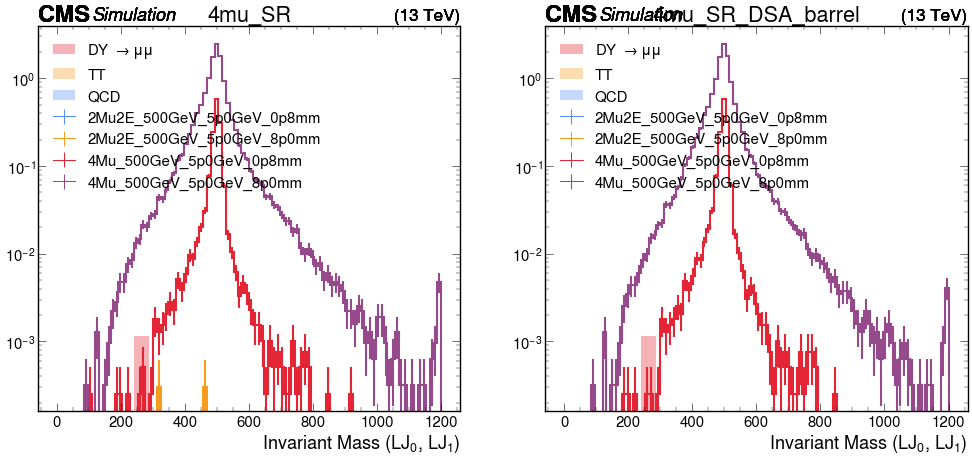

In [9]:
fig, axes = plt.subplots(1,2,figsize=(12*2,10))
hist = "lj_lj_invmass"

#Plot the first selection
plt.subplot(1, 2, 1)
#Sum the list of background hists into 1 main bkg hist for each bkg type
QCD_bkg_total = sum_bgs_hist(QCD, hist_collection_1, hist, channel_1)
TTJ_bkg_total = sum_bgs_hist(TT, hist_collection_1, hist, channel_1)
DY_bkg_total = sum_bgs_hist(DY, hist_collection_1, hist, channel_1)
#Plot all of the backgrounds stacked together
utilities.plot([QCD_bkg_total, TTJ_bkg_total, DY_bkg_total], density=False, histtype="fill", 
               label=["QCD", "TT", r"DY $\rightarrow \mu\mu$"], stack=True, yerr=True, alpha=.35, flow="none")
#Reset the coloring before plotting data
axes[0].set_prop_cycle(None)
#Plot the data
for i, plotting_sample in enumerate(samples):
    if i == 4: break #Don't go above 4 samples. 
    utilities.plot(out_1[plotting_sample]["hists"][hist][channel_1, :], density=False, label=plotting_sample, linewidth=3)
    # legend_list.append(plotting_sample)

plt.legend(loc='upper left')
plt.yscale("log")
axes[0].set_title(f"{channel_1}")

#------------------------------------------------------------------------------------------------------
#Plot the SECOND selection
plt.subplot(1, 2, 2)
#Sum the list of background hists into 1 main bkg hist for each bkg type
QCD_bkg_total = sum_bgs_hist(QCD, hist_collection_2, hist, channel_2)
TTJ_bkg_total = sum_bgs_hist(TT, hist_collection_2, hist, channel_2)
DY_bkg_total = sum_bgs_hist(DY, hist_collection_2, hist, channel_2)
#Plot all of the backgrounds stacked together
utilities.plot([QCD_bkg_total, TTJ_bkg_total, DY_bkg_total], density=False, histtype="fill", 
               label=["QCD", "TT", r"DY $\rightarrow \mu\mu$"], stack=True, yerr=True, alpha=.35, flow="none")
#Reset the coloring before plotting data
axes[1].set_prop_cycle(None)
#Plot the data
for i, plotting_sample in enumerate(samples):
    if i == 4: break #Don't go above 4 samples. 
    utilities.plot(out_2[plotting_sample]["hists"][hist][channel_2, :], density=False, label=plotting_sample, linewidth=3)
    # legend_list.append(plotting_sample)

plt.legend(loc='upper left')
plt.yscale("log")
axes[1].set_title(f"{channel_2}")


## Plotting All 4 Constituents (No Mask) (Bkg stacked)

NameError: name 'bkg_out' is not defined

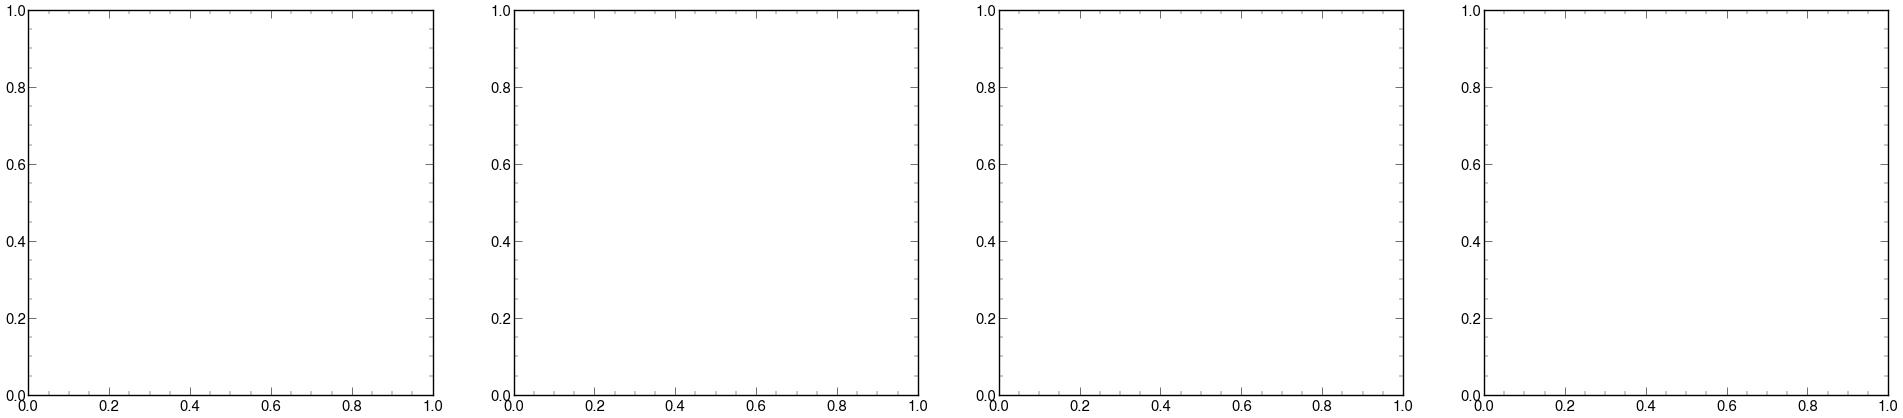

In [10]:
fig, axes = plt.subplots(1,4,figsize=(12*4,10))
hists = ["lj_muon_eta", "lj_dsaMuon_eta", "lj_electron_eta", "lj_photon_eta"]

for i, hist in enumerate(hists):
    legend_list = []
    plt.subplot(1, 4, i+1)
    #Loop over all of the backgrounds and put their hists into individual lists
    QCD_bkg_hists = []
    TTJ_bkg_hists = []
    DY_bkg_hists = []
    for bkg_plotting_sample in samples_bkg:
        bkg_hist = bkg_out[bkg_plotting_sample]["hists"][hist][channels[0], :]
        if "QCD" in bkg_plotting_sample:
            QCD_bkg_hists.append(bkg_hist)
        elif "TTJets" in bkg_plotting_sample:
            TTJ_bkg_hists.append(bkg_hist)
        elif "DYJets" in bkg_plotting_sample:
            DY_bkg_hists.append(bkg_hist)
    #Sum the list of background hists into 1 main bkg hist for each bkg type
    QCD_bkg_total = sum(QCD_bkg_hists)
    TTJ_bkg_total = sum(TTJ_bkg_hists)
    DY_bkg_total = sum(DY_bkg_hists)
    #Plot all of the backgrounds stacked together
    utilities.plot([QCD_bkg_total, TTJ_bkg_total, DY_bkg_total], density=False, histtype="fill", 
                   label=["QCD", "TT", r"DY $\rightarrow \mu\mu$"], stack=True, yerr=True, alpha=.35, flow="none")
    #Reset the coloring before plotting data
    axes[i].set_prop_cycle(None)
    #Plot the data
    for i, plotting_sample in enumerate(samples):
        if i == 4: break #Don't go above 4 samples. 
        utilities.plot(out[plotting_sample]["hists"][hist][channels[0], :], density=False, label=plotting_sample, linewidth=3)
        legend_list.append(plotting_sample)

    plt.legend(loc='upper left')
    plt.yscale("log")

# print(f"Handles:\n {handles}\n")
# print(f"Labels:\n {labels}\n")
# print(f"Dict:\n {handles_labels_dict}")


## Plotting All 4 Constituents (With Mask) (Bkg stacked)

In [ ]:
fig, axes = plt.subplots(1,4,figsize=(12*4,10))
hists = ["lj_muon_eta_dPhiMask", "lj_dsaMuon_eta_dPhiMask", "lj_electron_eta_dPhiMask", "lj_photon_eta_dPhiMask"]

for i, hist in enumerate(hists):
    legend_list = []
    plt.subplot(1, 4, i+1)
    #Loop over all of the backgrounds and put their hists into individual lists
    QCD_bkg_hists = []
    TTJ_bkg_hists = []
    DY_bkg_hists = []
    for bkg_plotting_sample in samples_bkg:
        bkg_hist = bkg_out[bkg_plotting_sample]["hists"][hist][channels[0], :]
        if "QCD" in bkg_plotting_sample:
            QCD_bkg_hists.append(bkg_hist)
        elif "TTJets" in bkg_plotting_sample:
            TTJ_bkg_hists.append(bkg_hist)
        elif "DYJets" in bkg_plotting_sample:
            DY_bkg_hists.append(bkg_hist)
    #Sum the list of background hists into 1 main bkg hist for each bkg type
    QCD_bkg_total = sum(QCD_bkg_hists)
    TTJ_bkg_total = sum(TTJ_bkg_hists)
    DY_bkg_total = sum(DY_bkg_hists)
    #Plot all of the backgrounds stacked together
    utilities.plot([QCD_bkg_total, TTJ_bkg_total, DY_bkg_total], density=False, histtype="fill", 
                   label=["QCD", "TT", r"DY $\rightarrow \mu\mu$"], stack=True, yerr=True, alpha=.35, flow="none")
    #Reset the coloring before plotting data
    axes[i].set_prop_cycle(None)
    #Plot the data
    for i, plotting_sample in enumerate(samples):
        if i == 4: break #Don't go above 4 samples. 
        utilities.plot(out[plotting_sample]["hists"][hist][channels[0], :], density=False, label=plotting_sample, linewidth=3)
        legend_list.append(plotting_sample)

    plt.legend(loc="upper left")
    plt.yscale("log")

# print(f"Handles:\n {handles}\n")
# print(f"Labels:\n {labels}\n")
# print(f"Dict:\n {handles_labels_dict}")
